# (리뷰) Dart, Liu2018
> 완료

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [논문리뷰]


### About this post

- 논문리뷰 / AutoML공부 

- 학부수준 

- 본 포스팅은 **Liu, H., Simonyan, K., & Yang, Y. (2018). Darts: Differentiable architecture search. arXiv preprint arXiv:1806.09055** 을 리뷰한 것이다. 해당논문은 https://arxiv.org/abs/1806.09055 에서 확인할 수 있다. 

### Introduction 
- Liu(2018)은 딥러닝 아키텍쳐를 자동으로 골라주는 방법에 대하여 논의한 것이다. 예를들면 특정 데이터를 분석하는 아키텍처를 구성할때 노드와 노드사이를 $3\times 3$ convolution으로 연결할지 혹은 $5 \times 5$ max pooling으로 연결할지등을 알아서 선택해준다는 것이다. 

- 즉 이 논문은 "인공지능을 만드는 인공지능"에 대해서 논의한다고 볼 수 있다. 

- 개인적으로 "인간은 정말 끝없이 게을러지고 싶어하는구나, 이제 하다못해 인공지능을 만드는 것도 귀찮아서 그것까지 인공지능에게 시키는구나.." 하는 생각이 들게 만드는 논문이었다. 

- 처음에는 "인공지능을 만드는 인공지능"을 설계한다는 것에 상당히 거부감이 있었다. 거부감이 생긴 이유는 1) 사람이 데이터를 보고 그거에 맞게 구조를 설계해야 한다고 생각했으며 2) 자동으로 아키텍처를 선택하기 위해서 너무 많은 계산을 컴퓨터에게 시키지 않을까? 하는 생각이 들어서이다. (가뜩이나 딥러닝자체도 컴퓨터에게 부담을 주는데 말이다)

- 1)을 좀 더 자세히 설명하면 분석하고 싶은 자료의 특징을 잘 살펴보고 DNN을 쓸것인지 CNN을 쓸것인지 RNN을 쓸것인지 결정해야하며 학습속도를 높이기 위해서 전처리를 어떻게 하면 좋을지도 고민해야 한다는 것이다. 또한 자료의 형태와 분석 목적에 따라서 loss function을 어떻게 설정할지도 고민해야 한다. 그 밖에도 딥러닝 전문가가 설계해야할 많은 과정이 있다. 논문이 제안하는 방법은 이러한 경우에 대한 고민없이 이 설계부분을 그저 "아 몰라, 그냥 설계도 인공지능이 알아서 해줘"라는 식으로 보여서 처음에는 거부감이 들었다. 

- 하지만 논문을 읽어보니 내가 오해했다는 것을 알 수 있었다. 딥러닝에서는 위에서 말한것과 같은 대략적인 아키텍쳐를 전문가가 설계하더라도 세부적으로는 최적의 설계를 뽑아내기 위해 약간의 "**튜닝**" 작업이 필요하다. 예를들면 $3\times 3$ convolution 을 선택할지 $5 \times 5$ convolution 을 선택할지와 같은 식으로 말이다. 이러한 부분은 데이터에 대한 어떠한 직관도 필요하지 않다. 그저 설계자가 순수한 "**노가다**"를 통해 경험적으로 터득할 수 있는 영역이다. Darts는 바로 이러한 영역에서 사용자의 노가다를 덜어주는 역할을 한다. 

- 논문에 대한 또다른 오해는 Darts가 컴퓨터를 너무 혹사시킨다는 것이었다. 그런데 어떻게 생각해보면 Darts가 아키텍처를 자동으로 선택하지 않으면 어차피 사람이 아키텍처를 이것저것 때려넣어보면서 튜닝을 해야하기 때문에 컴퓨터 입장에서 혹사 되는것은 비슷하다. 오히려 Darts가 사람보다 효율적으로 아키텍처를 찾아낼 확률이 높기 때문에 Darts가 컴퓨터를 덜 혹사시킨다고 생각할 수도 있다. 

- 다만 설계는 그대로 사용자의 손을 타야한다고 생각하는 입장에서 Darts가 그렇게 달갑지 않은 것은 사실이다. 따라서 이어질 글에서는 매우 비판적인 태도로 리뷰를 할 것이다. (나도 사람이기 때문에 어쩔 수 없다) 

### Darts (Differentialbe Architecture Search)

***Search Space***

- Darts에서 분석하고자 하는 자료는 **방향성비순환그래프(directed acyclic graph)**형태로 제한한다. 

- 방향성비순환그래프가 무엇인가? 방향성비순환그래프의 대표적인 예는 시계열 자료를 생각할 수 있다. 시계열 자료는 $X_t$시점에서 $X_{t+1}$의 시점으로 화살표가 있는(=방향성이 있는) 그래피컬 자료이다. 또한 방향성이 순환하지 않는 자료이다. 여기에서 $X_t$에서 $X_{t+1}$로의 방향성이 있다는 말은 $X_t$를 입력으로 하여 출력 $X_{t+1}$를 얻을 수 있다는 의미이며 순환하지 않는다는 말은 $X_t$에서 출발한 화살표를 따라서 어떠한 경로로 이동해도 $X_t$로 되돌아올 수 없다는 의미이다. 

- 방향성비순환그래프의 또 다른 예는 NN과 DNN 아키텍처이다. 

- 이 그림이 시사하는것은 임의의 딥러닝 아키텍처를 위와 같이 방향성비순환그래프의 형태로 표현가능하다는 것이다. 바로 이것이 저자들이 방향성비순환그래프로 자료의 형태를 제한한 이유이다. 앞으로는 그냥 편리하게 분석하고자 하는 자료의 형태를 위와같이 $N$개의 노드와 노드사이의 연결이 있는 DNN과 같은 아키텍처라고 생각하자. 

- 논문의 내용을 설명하기 위해서 노테이션들을 정리해보자. 노드는 모두 $N$개가 있으며 각각의 노드는 
$$
x^{(1)}, x^{(2)}, \dots, x^{(N)}
$$
와 같이 표시한다. 
그리고 $o^{(i,j)}(\cdot)$는 $j$번째 노드에서 $i$번째 노드로 가는 연산(operator)를 의미한다. 따라서 아래식이 성립한다. 
$$
x^{(i)}=\sum_{j<i} o^{(i,j)} \left( x^{(j)} \right)
$$

- 다음 섹션부터는 이러한 DNN 비슷한 아키텍쳐(=방향성비순환그래프)에서 어떻게 "인공지능을 설계하는 인공지능"을 만들 수 있는지 논의한다. 


***Continuous Relaxation and Optimization***


- 저자들이 원하는 것은 아래의 그림과 같이 아키텍쳐를 자동으로 골라주는 시스템을 구축하는 것이다. 
<img src="https://www.fast.ai/images/darts.png"/>

- 위의 그림은 Liu(2018)에 수록된 그림이다. (a)에서 (c)로 갈수록 노드들(=edge들) 사이의 operation을 학습한다. 여기에서 operation은 컨벌루션, max pooling등의 연산을 포함한다. 보는것처럼 그림에서는 총 3개(빨강, 파랑, 녹색)의 operation이 존재한다. (d)가 최종학습된 결과이다. 

- 위의 그림을 다시 설명하여 보자. ${\cal O}$를 어떠한 operation들의 집합이라고 하자. Liu(2018)의 Figure 1에서는 3개의 operation이 존재하므로 이경우 $\|{\cal O}\| =3$이다. 앞에서 말했듯이 $x^{(j)}$에서 $x^{(i)}$를 얻기 위해서는 operation $o^{(i,j)}$이 필요하다. 그런데 Liu(2018)의 Figure 1에서 보듯이 $o^{(i,j)}$는 하나의 연산만 존재하는 것이 아니라 총 $\|{\cal O}\|=3$개의 연산이 존재한다. 저자들의 아이디어는 이 연산들을 적당히 조합한 새로운 연산 $\bar{o}^{(i,j)}(\cdot)$를 찾아보자는 것이다. 

- 이때 새로운 연산 $\bar{o}^{(i,j)}(\cdot)$는 아래와 같이 기존연산들의 가중합으로 정의할 수 있다. 
$$
\bar{o}^{(i,j)}(x)=\sum_{o \in {\cal O}}\frac{\exp \left(\alpha_o^{(i,j)}\right)}{\sum_{o' \in {\cal O}} \exp\left( \alpha_{o'}^{(i,j)}\right)}o(x)
$$
각 연산들의 가중치는 $\alpha_o^{(i,j)}$에 저장한다. 따라서 $\alpha_o^{(i,j)}$는 크기가 $\|{\cal O}\|=3$인 벡터가 된다. 고정된 $(i,j)$에 대하여 벡터 $\alpha_o^{(i,j)}$들이 span하는 공간을 **search space**라고 하는데 이 공간을 연속적으로 만들기 위하여 위와 같은 softmax함수를 고려한다. 

- (개인의견) 논문전체에서 가장 인상깊었던 부분이 바로 이 부분이었다. 소프트맥스 함수를 도입하여 벡터 $\alpha_o^{(i,j)}$가 span하는 공간을 연속적이게 만든 부분이 논문중에서 가장 훌륭한 아이디어라 생각한다. 저자들은 이를 **continuous relaxation**이라고 표현하였다. 참고로 $\alpha_o^{(i,j)}$가 span하는 공간을 연속이라 생각하였기 때문에 미분을 정의할 수 있게 되었고 그 결과 추후에 소개할 Liu(2018)의 Algorithm 1이 동작할 수 있게 만들었다. (이는 일반적인 logistic regression을 수행하는 아이디어와 동일함) 또한 이 부분으로 인하여 아키텍쳐를 설계하는 일을 단순한 multiclass classification 문제로 치환할 수 있었다. 따라서 바로 이런 부분이 "AI를 만들어내는 AI" 라는 슬로건이 가능한 이유이라 생각한다. (물론 Sexena(2016), Ahmed(2017), Shin(2018)등이 비슷한 아이디어를 냈었지만 저자들의 방법은 CNN, RNN계열에 모두 사용할수 있고 나아가 Graph Topology로 표현가능한 어떠한 형태의 아티텍쳐로도 확장가능하다는 점에서 차별성을 가진다고 한다.)

- 우리의 목적은 $\alpha=\left\{ \alpha^{(i,j)} \right\}$를 학습하는 것이다. (그리고 이때의 $\alpha$를 (encoding of the) architecture라고 함)이는 결국 최적의 성능을 내는 operation들의 조합을 찾는것과 동치이다. 추후에 $\bar{o}^{(i,j)}$를 아래와 같이 
$$
o^{(i,j)}=\underset{o \in {\cal O}}{\operatorname{argmax}} \alpha_o^{(i,j)}
$$
로 대치한다. 이것은 Liu(2018)의 Figure 1 (c)에서 Figure 1 (d)로 이동하는 과정을 의미한다. 

- "AI를 만들어내는 AI"를 구현하기 위해서는 최적의 성능을 내는 operation들의 조합 $\alpha=\left\{ \alpha^{(i,j)}\right\}$와 그에 대응하는 웨이트 $w$를 동시에 학습하는 손실함수를 고려해야 한다. 따라서 아래와 같은 최적화 문제를 고려한다. 
$$
\min_ {\alpha} {\cal L}_ {val}(w^* (\alpha),\alpha) ~~~ s.t ~~~ w^* (\alpha)=\underset{w}{\operatorname{argmin}} {\cal L}_ {train}(w,\alpha)
$$

- 위의 식에서 ${\cal L}_ {val}$은 **validation loss**를, ${\cal L}_ {train}$은 **training loss**를 의미한다. 위의 식은 제약조건이 있는 최적화 문제이며 비선형방정식이므로 이 방정식을 푸는것은 어렵다(=못푼다). 따라서 이러한 문제를 해결하기 위해서는 알고리즘적으로 접근하여 해를 근사시켜야 한다. 구체적인 알고리즘은 다음섹션에서 설명한다. 


***Approximation***

- 저자들은 
$$
\min_ {\alpha} {\cal L}_ {val}(w^* (\alpha),\alpha) ~~~ s.t ~~~ w^* (\alpha)=\underset{w}{\operatorname{argmin}} {\cal L}_ {train}(w,\alpha)
$$
를 풀기위해서 $(w,\alpha)$를 iterative하게 update하는 방법을 제안하였다. 즉 저자들은 아래의 알고리즘을 제안하였다. 

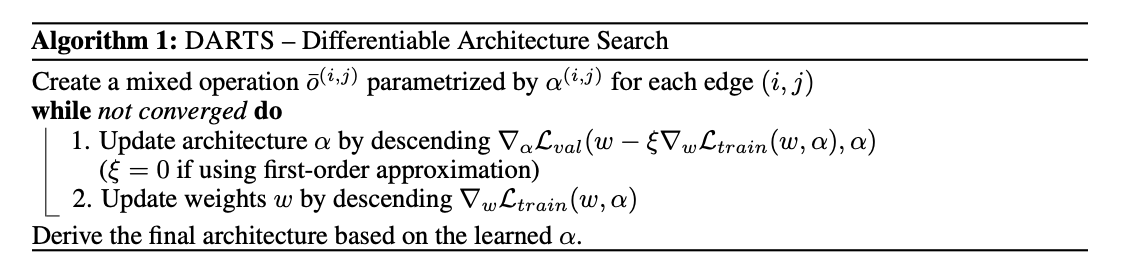


- 참고로 이런류의 알고리즘(dual update)은  수렴성을 반드시 보장할수는 없다. 저자들은 이 알고리즘의 수렴성을 보장하기 위한 최소한의 가정을 p.4 line 6-12에 걸쳐 휴리스틱하게 설명하였다. 또한 저자들은 제안된 알고리즘의 수렴성을 증명하지는 못하였지만 학습률 $\xi$를 잘 조정하면 위의 알고리즘이 practically working한다고 주장한다. 

- 잠깐 $\xi$에 대하여 살펴보자. 일반적인 경사하강법(Gradient descent)에서 학습률은 stepsize를 의미하는데 여기에서는 약간 의미가 다르다. 저자들의 Algoritm 1을 살펴보면 $\xi=0$일경우 first-order approximation이 된다. 결국 $\xi$는 first-order와 second-order approximation에 각각 얼만큼의 가중치를 두고 학습할 것이냐를 결정하는 파라메터이다. 다만 $\xi$를 조절함에 따라서 얼만큼 빠르게 local min을 향해갈것인지 조절한다는 의미는 동일하므로 저자들이 학습률이라는 단어로 표현하것 같다. 일반적으로 우리가 알고있는 학습률(=stepsize)는 $\eta_w$, $\eta_{\alpha}$와 같이 표현하였으며 저자들은 이 값을 고정하여 시뮬레이션을 수행하였다. (Section 3, Experiments and Results 참고)

- 아래는 Liu(2018)에 수록된 그림이다. 이 그림은 $\xi$에 따라 알고리즘이 적절한 $(\alpha,w)$를 빠르게 찾을수도 느리게 찾을수도 있음을 보여준다. 아래그림의 상황에서 초기값은 $(\alpha,w)=(2,-2)$이고 최적해는 $(1,1)$에 위치한다. 서로 다른 $\xi$에 따라 최적해에 접근하는 경로가 제각각이다. 이 경우 $\xi=0.5$일 경우(초록색실선) 가장 **잘(=빠르고 정확하게)** 수렴하는듯 보인다.
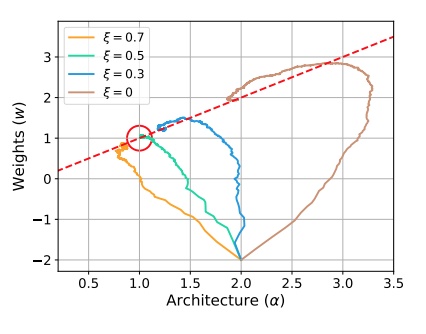

- 아무튼 저자들은 Algorithm 1을 제안하였다. 그리고 이 Algorithm 1에서 
$$
\bigtriangledown_{\alpha}{\cal L}_ {val}(w- \xi \bigtriangledown_w {\cal L}_ {train}(w,\alpha),\alpha)
$$
부분에 대한 계산을 혁신적으로 개선하여 알고리즘의 수렴속도를 크게 향상시켰다. 

- 이 과정을 좀더 자세히 살펴보자. 위의식을 계산하면 아래와 같이 표현할 수 있다. (한번에 암산이 안되는 나같은 사람을 위해서 좀 더 상세한 과정을 Appendix에 수록하였음)
$$
\bigtriangledown_ {\alpha}{\cal L}_ {val}(w',\alpha)
=\bigtriangledown_ {\alpha}{\cal L}_ {val}(w',\alpha)-\xi \bigtriangledown^2_ {\alpha,w} {\cal L}_ {train}(w,\alpha) \bigtriangledown_{w'}{\cal L}_ {val}(w',\alpha) 
$$
이때 $w'=w- \xi \bigtriangledown_w {\cal L}_ {train}(w,\alpha)$을 의미한다. 

-  위의식에서 가장 많은 시간이 걸리는 부분은 당연히 헤시안매트릭스를 계산하는 $\bigtriangledown^2_ {\alpha,w}$부분이다. 저자들은 연속적인 domain에서 정의된다고 가정한 (encoding of the) architecture $\alpha$가 사실은 finite dimension을 가진다는 것에 착안하여 $\|\alpha\| \|w\|$ 개의 모든 그레디언트를 고려하지 않아도 좋다고 생각했다. 대신에 임의의 작은 $\epsilon$에 대하여 아래의 2개의 $w$만 고려하기로 했다. 
$$
\begin{cases}
w^+ = w + \epsilon  \bigtriangledown_ {w'}{\cal L}_ {val}(w',\alpha)\\ w^- = w - \epsilon  \bigtriangledown_ {w'}{\cal L}_ {val}(w',\alpha)
\end{cases}
$$
따라서 아래가 성립하게 된다. 
$$
\bigtriangledown^2_ {\alpha,w} {\cal L}_ {train}(w,\alpha) \bigtriangledown_ {w'}{\cal L}_ {val}(w',\alpha)  \approx \frac{\bigtriangledown_ {\alpha} {\cal L}_ {train}(w^+,\alpha)-\bigtriangledown_ {\alpha} {\cal L}_ {train}(w^-,\alpha)}{2 \epsilon}
$$
따라서 complexity는 $O(|\alpha| |w|)$에서 $O(|\alpha|+|w|)$로 줄어들게 된다. 

- (개인의견) 개인적으로 현재까지의 argument는 $|\alpha|$가 작을때에만 성립하기 때문에 좀 더 다양한 아키텍처를 고려해야 하는 모델에서는 **Darts**가 가지는 장점(=빠른속도)이 사라지게 될것이라 생각한다. 또한 알고리즘 1을 구성할때는 $\alpha$가 연속적인 도메인에서 정의된다고 가정하여 놓고 (그래야 느리지만 안전한 수렴성을 보장하므로) 정작 실제 구현방식에서는 $\alpha$가 사실 finite 도메인에 존재함을 이용하여
$$
\bigtriangledown^2_ {\alpha,w} {\cal L}_ {train}(w,\alpha) \bigtriangledown_{w'}{\cal L}_ {val}(w',\alpha)  \approx \frac{\bigtriangledown_ {\alpha} {\cal L}_ {train}(w^+,\alpha)-\bigtriangledown_{\alpha} {\cal L}_ {train}(w^-,\alpha)}{2 \epsilon}
$$
와 같은 근사를 사용하였다. 이는 $\alpha$의 모수공간을 아전인수식으로 해석하고 있다고 생각할 수도 있다. 

- (개인의견) 저자들의 방법은 안정성과 속도사이의 밸렁싱을 맞추는것이 상당히 아슬아슬하게 느껴진다. 이것을 컨트롤 하는 역할을 $\xi$가 하고 있는데 이러한 $\xi$를 항상 잘 선택할 수 있을것인지에 대한 의문이 남는다. (그리고 이와 관련된 내용을 저자들도 Liu(2018) p.4, First-order Approximation에서 언급하였음) 저자들은 $\xi$를 선택하는 방법에 대하여 논의하지 않고 있기 때문에 $\xi$를 잘 선택하는 것은 오로지 사용자의 몫이다. 개인적인 의견으로는 거의 예술적으로 $\xi$를 선택해야만 알고리즘이 돌아갈것 같다. 

- (개인의견) Liu(2019)의 논문에서 table 1과 table 2에 $\xi=0$으로 했을 경우와 그렇지 않을 경우에 대한 성능이 소개되어있다. 테이블들은 본 포스팅에서는 첨부하지 않았다. 알아서 찾아보기 바란다. 개인적인 의견으로는 정확률을 다소 포기하더라도 first order인 경우를 사용하는 것이 좋다고 느껴진다. 그리고 이 경우는 $\xi=0$이 되어서 $\bigtriangledown^2_ {\alpha,w}$의 계산을 아예 고려하지 않아도 된다. 즉 이렇게 되면 저자들이 주장하는 업적중 하나인 "complexity 감소" 즉 
$$
O(|\alpha| |w|) \rightarrow O(|\alpha|+|w|)
$$
와 같은 감소는 공허한 메이리에 지나지 않는다. 

### Experiments and Results
- 이 섹션부터는 그냥 본인들 결과에 대한 실험내용을 정리한 것이다. 특별히 개념적으로 이해할 부분이 없으므로 포스팅할 내용이없다. 

- 실험결과는 각자 논문을 확인해보길 바란다. ~~(결국 자기들 방법이 좋다는 소리임)~~

### Concluding remark
- 기본적으로 "AI를 만드는 AI를 만들자"라는 슬로건에 동의하지는 않는다. ~~(말도 더럽게 복잡함)~~ 

- 이런류의 연구가 유행하는 것 같긴한데 이런거 사용하는법을 익히는 시간에 공부를 더 하는게 좋을것 같다. 

- 다만 본 논문은 사용자가 아키텍처를 설계할때 "노가다"를 통해 경험적으로 알아야 할 영역을 ~~(흔히 말하는 때려맞추는..)~~ 자동으로 셋팅해준다는 점에서 의의가 있어보인다. 

### Appendix 
- 아래식이 성립함을 증명(?)하여 보자. 
$$
\bigtriangledown_ {\alpha}{\cal L}_ {val}(w',\alpha)
=\bigtriangledown_ {\alpha}{\cal L}_ {val}(w',\alpha)-\xi \bigtriangledown^2_ {\alpha,w} {\cal L}_ {train}(w,\alpha) \bigtriangledown_{w'}{\cal L}_ {val}(w',\alpha) 
$$
이때 $w'=w- \xi \bigtriangledown_w {\cal L}_ {train}(w,\alpha)$을 의미한다. 

- $z(x,y)$, $x=f(t)$, $y=f(t)$와 같다고 가정하자. 체인룰에 의하여 $\frac{dz}{dt}$는 아래와 같이 정의할 수 있다. 
$$
\frac{dz}{dt}=\frac{\partial z}{\partial x}\frac{dx}{dt}+\frac{\partial z}{\partial y}\frac{dy}{dt}
$$

- $w'=w-\xi \bigtriangledown_w {\cal L}_ {train}(w,\alpha)$가 $\alpha$의 함수인것을 감안하여 (1) $z={\cal L}_ {val}(w',\alpha)$ (2) $w'=f(\alpha)=x$, (3) $\alpha=y$ 와 같이 대입하고 위의 체인룰을 적용하면 아래와 같은 식이 성립함을 쉽게 알 수 있다. 
$$
\bigtriangledown_{\alpha}{\cal L}_ {val}(w',\alpha)=\bigtriangledown_{\alpha}{\cal L}_ {val}(w',\alpha)+\bigtriangledown_{w'}{\cal L}_ {val}(w',\alpha)\bigtriangledown_{\alpha}w'
$$


- 이때 
$$
\bigtriangledown_ {\alpha}w'=-\xi \bigtriangledown^2_ {\alpha,w} {\cal L}_ {train}(w,\alpha)
$$
이므로 아래가 성립한다. 
$$
\bigtriangledown_{\alpha}{\cal L}_ {val}(w',\alpha)=\bigtriangledown_{\alpha}{\cal L}_ {val}(w',\alpha)-\xi \bigtriangledown^2_ {\alpha,w} {\cal L}_ {train}(w,\alpha) \bigtriangledown_{w'}{\cal L}_ {val}(w',\alpha) 
$$

### Reference
- Ahmed, K., & Torresani, L. (2017). Connectivity learning in multi-branch networks. arXiv preprint arXiv:1709.09582.
- Liu, H., Simonyan, K., & Yang, Y. (2018). Darts: Differentiable architecture search. arXiv preprint arXiv:1806.09055.
- Saxena, S., & Verbeek, J. (2016). Convolutional neural fabrics. In Advances in Neural Information Processing Systems (pp. 4053-4061).
- Shin, R., Packer, C., & Song, D. (2018). Differentiable Neural Network Architecture Search.